In [1]:
import numpy as np
import matplotlib.pyplot as plt

## CML "Theta Dynamics"

**Map**: $\theta_{n+1,i} = (f(\theta_{n,i}) + \varepsilon/2(f(\theta_{n,i+1}) + f(\theta_{n,i-1})) \pmod{1}$

**Map**: $f(\theta) = \theta + \omega - \frac{K}{2\pi}\sin(2\pi\theta)$

- $\theta \in [0, 1]$ (angle normalized to unit circle)
- $\omega \in [0,1)$
- $K$ = nonlinearity parameter
- $\varepsilon$ = coupling strength between neighbors

In [2]:
# Setting up parameters
N       = 100   # Number of lattice sites (spatial dimension)
T       = 300   # Number of time steps
omega   = 0.5   
K       = 1   # Nonlinearity parameter (controls chaos)
epsilon = 0.3   # Coupling strength (0 = no coupling, 1 = max coupling)

In [3]:
# Initial conditions
np.random.seed(42)            # Makes the randomness reproducible
theta = np.random.rand(N)     # Each of the 100 sites gets a random starting phase in [0, 1)

In [4]:
def rotational_map(theta, omega, K):
    return (theta + omega - (K / (2 * np.pi)) * np.sin(2 * np.pi * theta))

In [5]:
# Storage
history = np.zeros((T, N))
history[0] = theta  # Store initial state in the first row of history

In [6]:
# Time evolution with spatial coupling
for t in range(1, T):
    f_theta  = rotational_map(theta, omega, K)     # Map every site
    f_left   = np.roll(f_theta,  1)                # Left neighbor's mapped phase
    f_right  = np.roll(f_theta, -1)               # Right neighbor's mapped phase
    
    # CML coupling: average with neighbors
    theta = ((1 - epsilon) * f_theta + (epsilon / 2) * (f_left + f_right)) % 1
    
    history[t] = theta

print("Done. history.shape =", history.shape)

Done. history.shape = (300, 100)


In [7]:
print("Min phase:", history.min().round(3))   
print("Max phase:", history.max().round(3))   
print("Sample row (t=0):", history[0, :5])   # Initial conditions
print("Sample row (t=1):", history[1, :5])   # first update

Min phase: 0.0
Max phase: 1.0
Sample row (t=0): [0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]
Sample row (t=1): [0.83426688 0.37222233 0.37664221 0.12087509 0.62390881]


#### Plotting the characteristic graphs

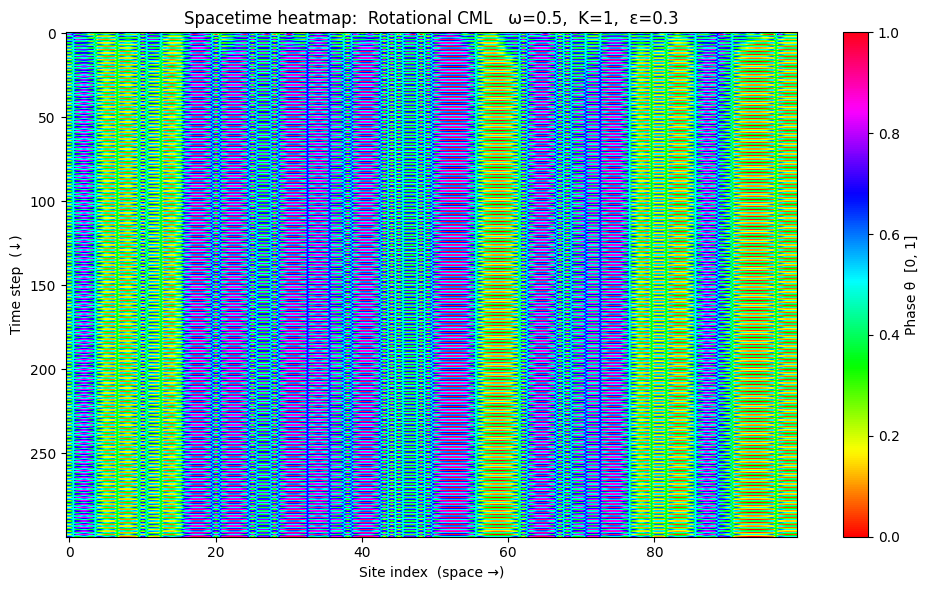

In [8]:
# Spacetime Heatmap (Spatiotemporal evolution)

plt.figure(figsize=(10, 6))

plt.imshow(history, aspect='auto', cmap='hsv', origin='upper', vmin=0, vmax=1)

plt.colorbar(label='Phase θ  [0, 1]')
plt.xlabel('Site index  (space →)')
plt.ylabel('Time step  (↓)')
plt.title(f'Spacetime heatmap:  Rotational CML   ω={omega},  K={K},  ε={epsilon}')
plt.tight_layout()

plt.savefig("Spacetime_Heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

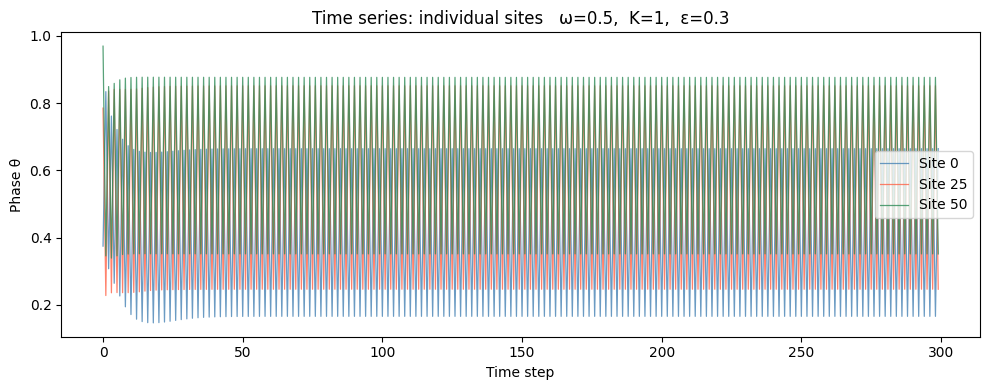

Time series plotted: different sites show their individual evolution


<Figure size 640x480 with 0 Axes>

In [9]:
# Single Site Time Series Evolution
plt.figure(figsize=(10, 4))

# Plot phases from 3 different sites
sites_to_plot = [0, N//4, N//2]     # sites 0, 25, and 50 (spread across lattice)
colors = ['steelblue', 'tomato', 'seagreen']

for site, color in zip(sites_to_plot, colors):
    plt.plot(history[:, site],    
             label=f'Site {site}',
             color=color,
             alpha=0.8,
             linewidth=0.9)

plt.xlabel('Time step')
plt.ylabel('Phase θ')
plt.title(f'Time series: individual sites   ω={omega},  K={K},  ε={epsilon}')
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig(f'Time_series_ω{omega}_K{K}_ε{epsilon}.png', dpi=300, bbox_inches='tight')
print("Time series plotted: different sites show their individual evolution")

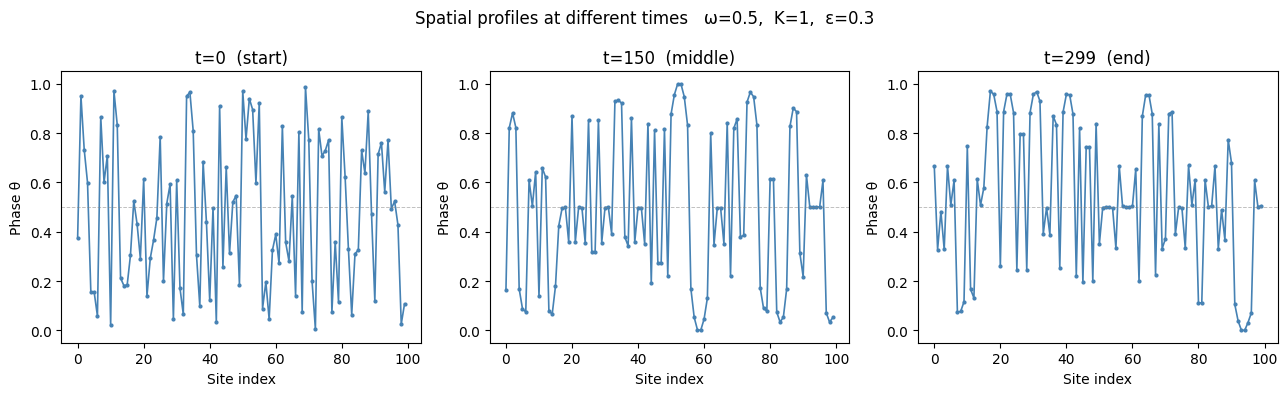

Spatial snapshots show how the phase profile evolves


In [10]:
# Spatial Snapshots at Different Times


fig, axes = plt.subplots(1, 3, figsize=(13, 4))

snapshots = [0, T//2, T-1]          # early, middle, and late time
labels    = ['t=0  (start)', f't={T//2}  (middle)', f't={T-1}  (end)']

for ax, t_snap, label in zip(axes, snapshots, labels):
    ax.plot(history[t_snap, :],     # all sites at this one moment
            color='steelblue',
            linewidth=1.2,
            marker='o',
            markersize=2)
    ax.set_title(label)
    ax.set_xlabel('Site index')
    ax.set_ylabel('Phase θ')
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.5, color='gray',   # reference line at θ=0.5
               linestyle='--', linewidth=0.7, alpha=0.5)

plt.suptitle(f'Spatial profiles at different times   ω={omega},  K={K},  ε={epsilon}')
plt.tight_layout()
plt.savefig(f'Spatial_Snapshots_ω{omega}_K{K}_ε{epsilon}.png', dpi=300, bbox_inches='tight')
plt.show()
print("Spatial snapshots show how the phase profile evolves")

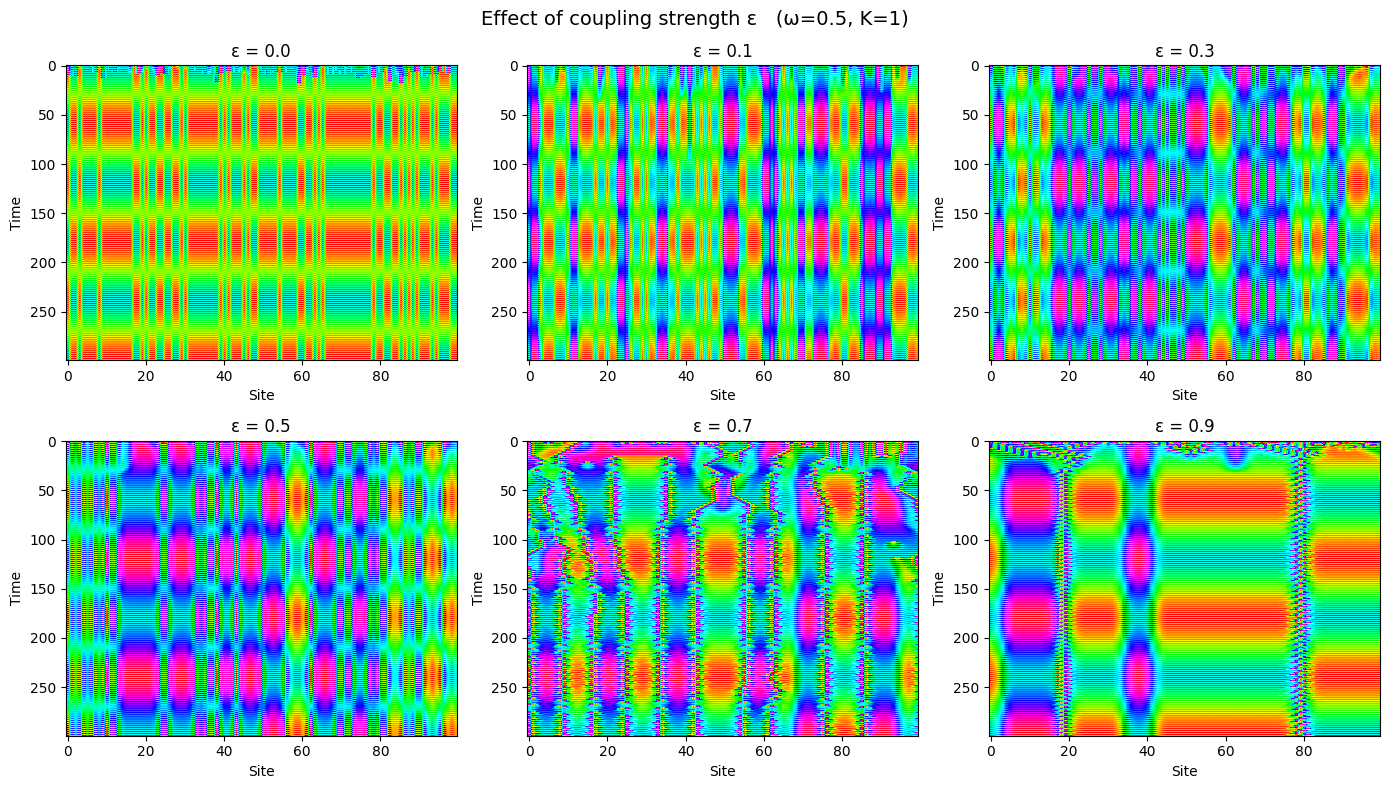

 Parameter sweep over ε shows transition from chaos to synchronization


In [11]:
# Effect of Coupling Strength ε (Varying ε)

epsilons = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()          # turn 2×3 grid into a flat list of 6 axes

for ax, eps in zip(axes, epsilons):

    # Re-run the CML with this epsilon
    np.random.seed(42)         # same seed every time — fair comparison!
    theta_temp = np.random.rand(N)
    hist = np.zeros((T, N))
    hist[0] = theta_temp

    for t in range(1, T):
        f_theta_temp  = rotational_map(theta_temp, omega, K)
        f_left_temp   = np.roll(f_theta_temp,  1)
        f_right_temp  = np.roll(f_theta_temp, -1)
        theta_temp    = ((1 - eps) * f_theta_temp + 
                         (eps / 2) * (f_left_temp + f_right_temp)) % 1
        hist[t]       = theta_temp

    # Plot spacetime heatmap for this ε value
    ax.imshow(hist, aspect='auto', cmap='hsv',
              origin='upper', vmin=0, vmax=1)
    ax.set_title(f'ε = {eps}', fontsize=12)
    ax.set_xlabel('Site')
    ax.set_ylabel('Time')

plt.suptitle(f'Effect of coupling strength ε   (ω={omega}, K={K})', fontsize=14)
plt.tight_layout()
plt.savefig('Coupling_Strength_Sweep.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Parameter sweep over ε shows transition from chaos to synchronization")

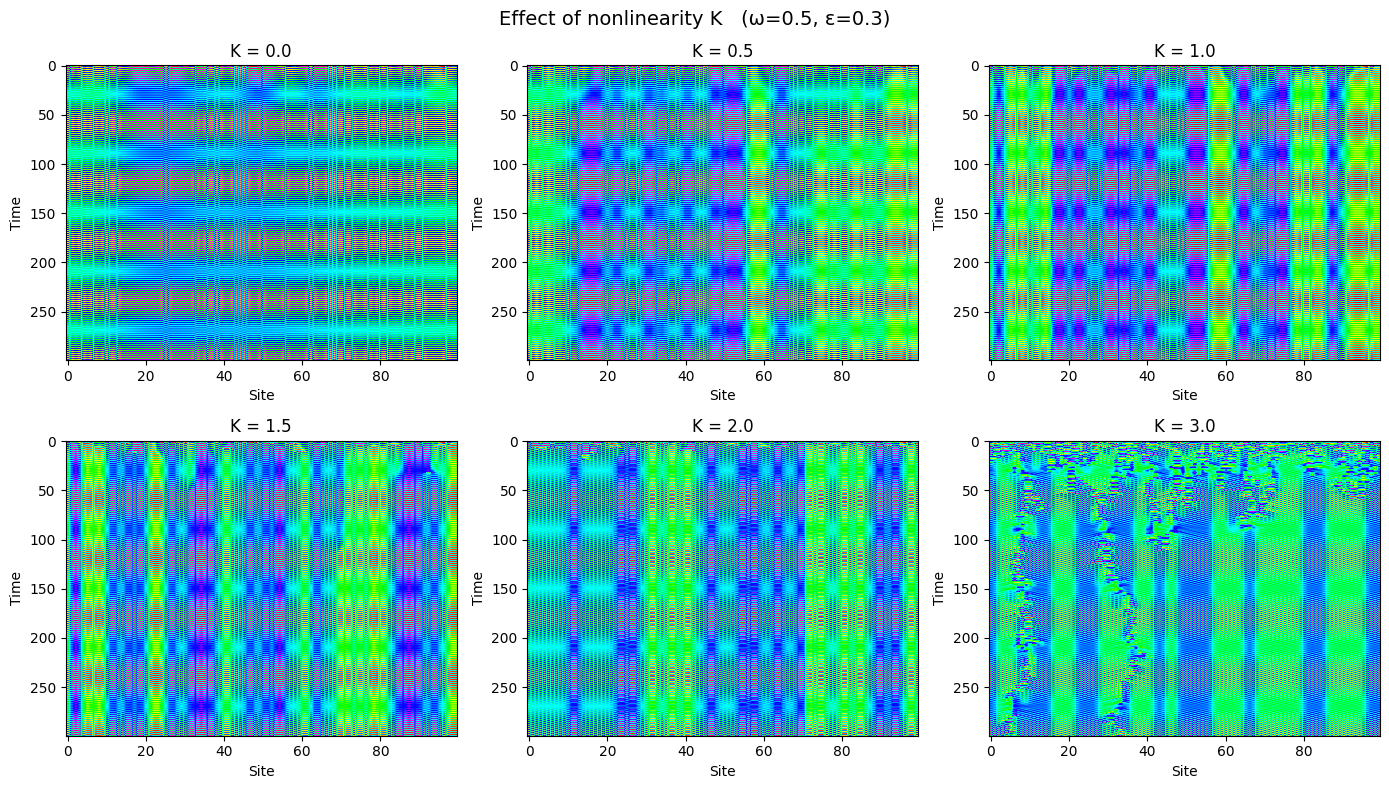

 Parameter sweep over K shows effect of nonlinearity on dynamics


In [12]:
# Effect of Nonlinearity K (Varying K)

K_values = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, K_val in zip(axes, K_values):

    np.random.seed(42)
    theta_temp = np.random.rand(N)
    hist = np.zeros((T, N))
    hist[0] = theta_temp

    # For each K value, run the full simulation
    for t in range(1, T):
        f_theta_temp  = rotational_map(theta_temp, omega, K_val)
        f_left_temp   = np.roll(f_theta_temp,  1)
        f_right_temp  = np.roll(f_theta_temp, -1)
        theta_temp    = ((1 - epsilon) * f_theta_temp + 
                         (epsilon / 2) * (f_left_temp + f_right_temp)) % 1
        hist[t]       = theta_temp

    # Plot
    ax.imshow(hist, aspect='auto', cmap='hsv',
              origin='upper', vmin=0, vmax=1)
    ax.set_title(f'K = {K_val}', fontsize=12)
    ax.set_xlabel('Site')
    ax.set_ylabel('Time')

plt.suptitle(f'Effect of nonlinearity K   (ω={omega}, ε={epsilon})', fontsize=14)
plt.tight_layout()
plt.show()
print(" Parameter sweep over K shows effect of nonlinearity on dynamics")

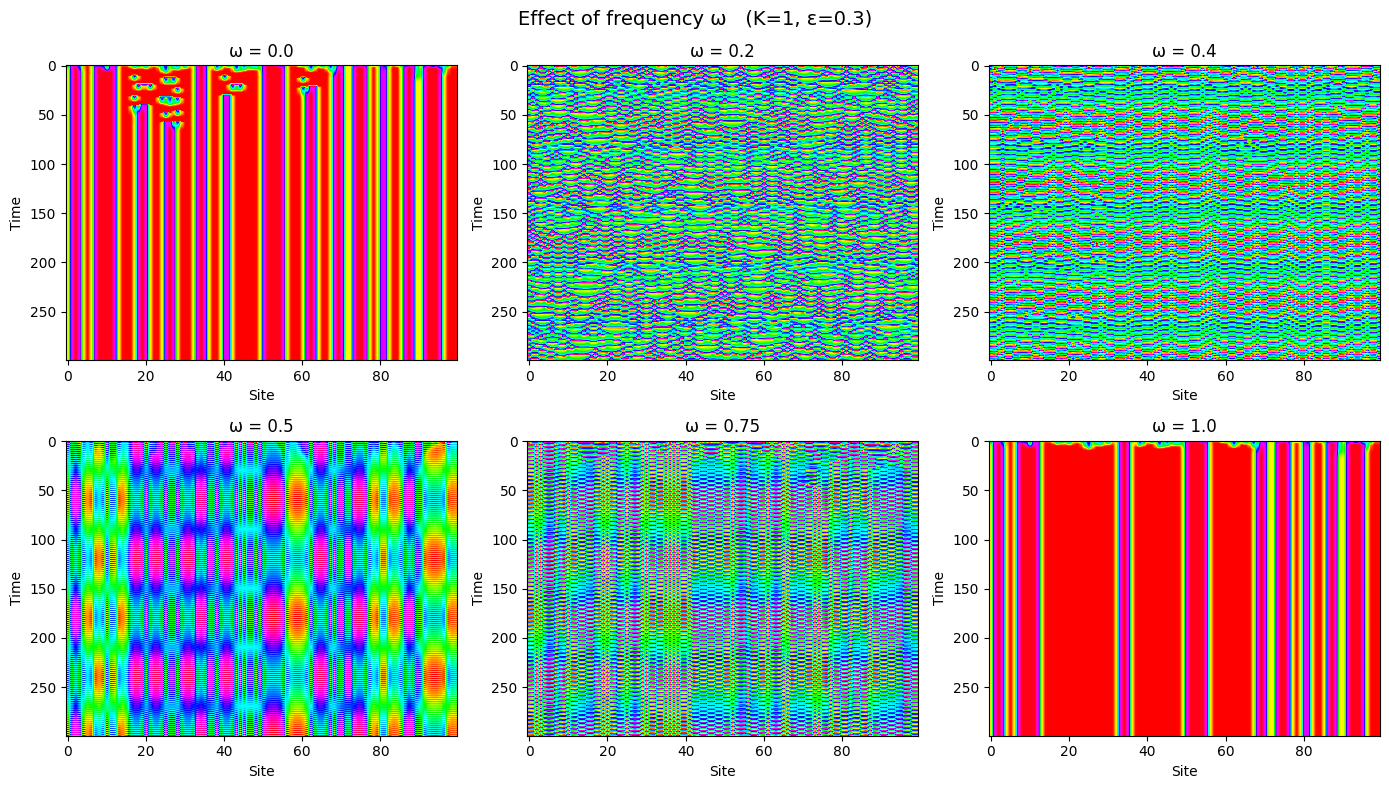

 Parameter sweep over ω shows effect of rotation frequency


In [13]:
# Effect of Frequency ω (Varying ω)
# ω controls the rotation rate of each oscillator
# Different ω can create interesting interference patterns

omega_values = [0.0, 0.2, 0.4, 0.5, 0.75, 1.0]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, omega_val in zip(axes, omega_values):

    np.random.seed(42)
    theta_temp = np.random.rand(N)
    hist = np.zeros((T, N))
    hist[0] = theta_temp

    # Simulate with this omega value
    for t in range(1, T):
        f_theta_temp  = rotational_map(theta_temp, omega_val, K)
        f_left_temp   = np.roll(f_theta_temp,  1)
        f_right_temp  = np.roll(f_theta_temp, -1)
        theta_temp    = ((1 - epsilon) * f_theta_temp + 
                         (epsilon / 2) * (f_left_temp + f_right_temp)) % 1
        hist[t]       = theta_temp

    ax.imshow(hist, aspect='auto', cmap='hsv',
              origin='upper', vmin=0, vmax=1)
    ax.set_title(f'ω = {omega_val}', fontsize=12)
    ax.set_xlabel('Site')
    ax.set_ylabel('Time')

plt.suptitle(f'Effect of frequency ω   (K={K}, ε={epsilon})', fontsize=14)
plt.tight_layout()
plt.savefig('Frequency_Sweep.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Parameter sweep over ω shows effect of rotation frequency")

In [14]:
# Local Coherence / Phase Variability
# Measure how much each individual site's phase changes over time.
# Compute standard deviation of phase for each site (across all time steps)
phase_coherence = np.std(history, axis=0) 

print(f"  Local phase coherence computed")
print(f"  Average phase variability: {phase_coherence.mean():.4f}")
print(f"  Sites with high coherence (<0.1 std): {np.sum(phase_coherence < 0.1)} out of {N}")
print(f"  Max variability at any site: {phase_coherence.max():.4f}")
print(f"  Min variability at any site: {phase_coherence.min():.4f}")

  Local phase coherence computed
  Average phase variability: 0.2516
  Sites with high coherence (<0.1 std): 0 out of 100
  Max variability at any site: 0.3142
  Min variability at any site: 0.1990


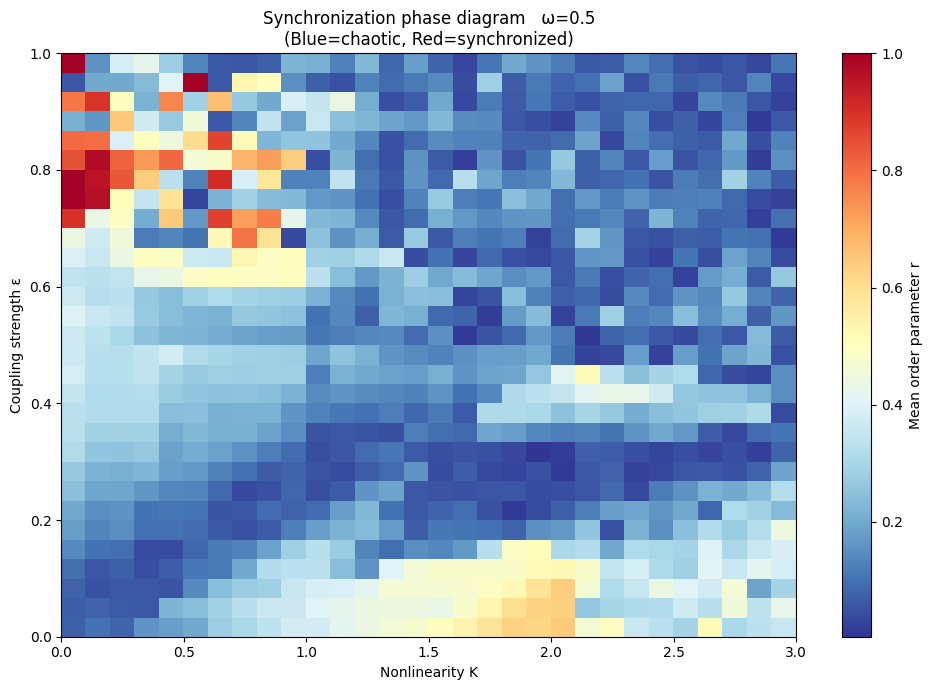

 Phase diagram computed
  Red regions: strong synchronization (high r)
  Blue regions: incoherent/chaotic dynamics (low r)


In [16]:
# Synchronization Phase Diagram - Coupling vs Nonlinearity
# Creating a 2D map showing mean synchronization level r as a function of (K, ε)

K_range_pd = np.linspace(0, 3, 30)     # K parameter sweep (fewer points)
eps_range_pd = np.linspace(0, 1, 30)   # epsilon parameter sweep
phase_diagram = np.zeros((len(eps_range_pd), len(K_range_pd)))

T_phase = 200  # Shorter simulation for phase diagram

for i, eps_val in enumerate(eps_range_pd):
    for j, K_val in enumerate(K_range_pd):
        # Run CML
        np.random.seed(42)
        theta_temp = np.random.rand(N)
        
        for t in range(1, T_phase):
            f_theta_temp = rotational_map(theta_temp, omega, K_val)
            f_left_temp = np.roll(f_theta_temp, 1)
            f_right_temp = np.roll(f_theta_temp, -1)
            theta_temp = ((1 - eps_val) * f_theta_temp + 
                         (eps_val / 2) * (f_left_temp + f_right_temp)) % 1
        
        # Compute mean synchronization (last 100 steps)
        theta_end = theta_temp
        for t in range(100):
            f_theta_temp = rotational_map(theta_end, omega, K_val)
            f_left_temp = np.roll(f_theta_temp, 1)
            f_right_temp = np.roll(f_theta_temp, -1)
            theta_end = ((1 - eps_val) * f_theta_temp + 
                        (eps_val / 2) * (f_left_temp + f_right_temp)) % 1
        
        # Order parameter
        angles_end = 2 * np.pi * theta_end
        r_end = np.abs(np.mean(np.exp(1j * angles_end)))
        phase_diagram[i, j] = r_end

plt.figure(figsize=(10, 7))
plt.imshow(phase_diagram, aspect='auto', cmap='RdYlBu_r', origin='lower',
           extent=[K_range_pd.min(), K_range_pd.max(), eps_range_pd.min(), eps_range_pd.max()])
plt.colorbar(label='Mean order parameter r')
plt.xlabel('Nonlinearity K')
plt.ylabel('Coupling strength ε')
plt.title(f'Synchronization phase diagram   ω={omega}\n(Blue=chaotic, Red=synchronized)')
plt.tight_layout()
plt.savefig('Synchronization_Phase_Diagram.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Phase diagram computed")
print("  Red regions: strong synchronization (high r)")
print("  Blue regions: incoherent/chaotic dynamics (low r)")

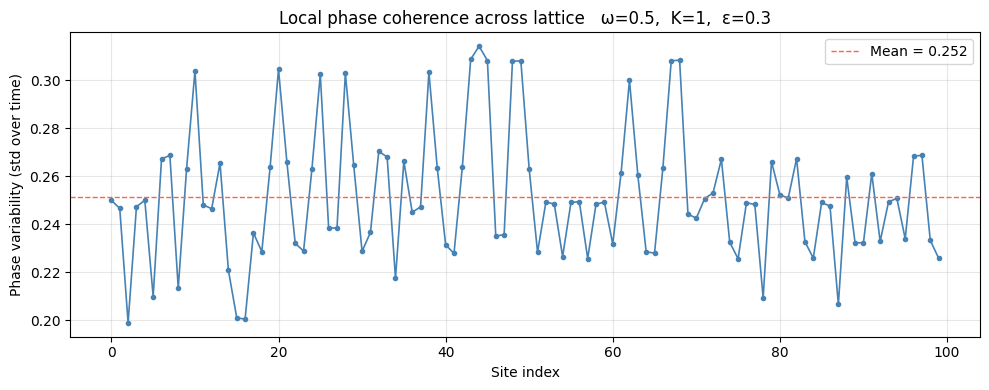

  Phase coherence analysis:
  Average phase variability: 0.2516
  Sites with high coherence (<0.1 std): 0 out of 100
  Most variable site: index 44, std=0.3142
  Most coherent site: index 2, std=0.1990


In [19]:
# Local Phase Coherence Pattern
# Plotting spatial distribution of phase variability
# High coherence sites = "pinned" oscillators
# Chaotic sites = independent/incoherent local dynamics

plt.figure(figsize=(10, 4))
plt.plot(phase_coherence, color='steelblue', linewidth=1.2, marker='o', markersize=3)
plt.xlabel('Site index')
plt.ylabel('Phase variability (std over time)')
plt.title(f'Local phase coherence across lattice   ω={omega},  K={K},  ε={epsilon}')
plt.axhline(phase_coherence.mean(), color='tomato', linestyle='--', 
            linewidth=1, label=f'Mean = {phase_coherence.mean():.3f}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Local_Phase_Coherence.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"  Phase coherence analysis:")
print(f"  Average phase variability: {phase_coherence.mean():.4f}")
print(f"  Sites with high coherence (<0.1 std): {np.sum(phase_coherence < 0.1)} out of {N}")
print(f"  Most variable site: index {np.argmax(phase_coherence)}, std={phase_coherence.max():.4f}")
print(f"  Most coherent site: index {np.argmin(phase_coherence)}, std={phase_coherence.min():.4f}")

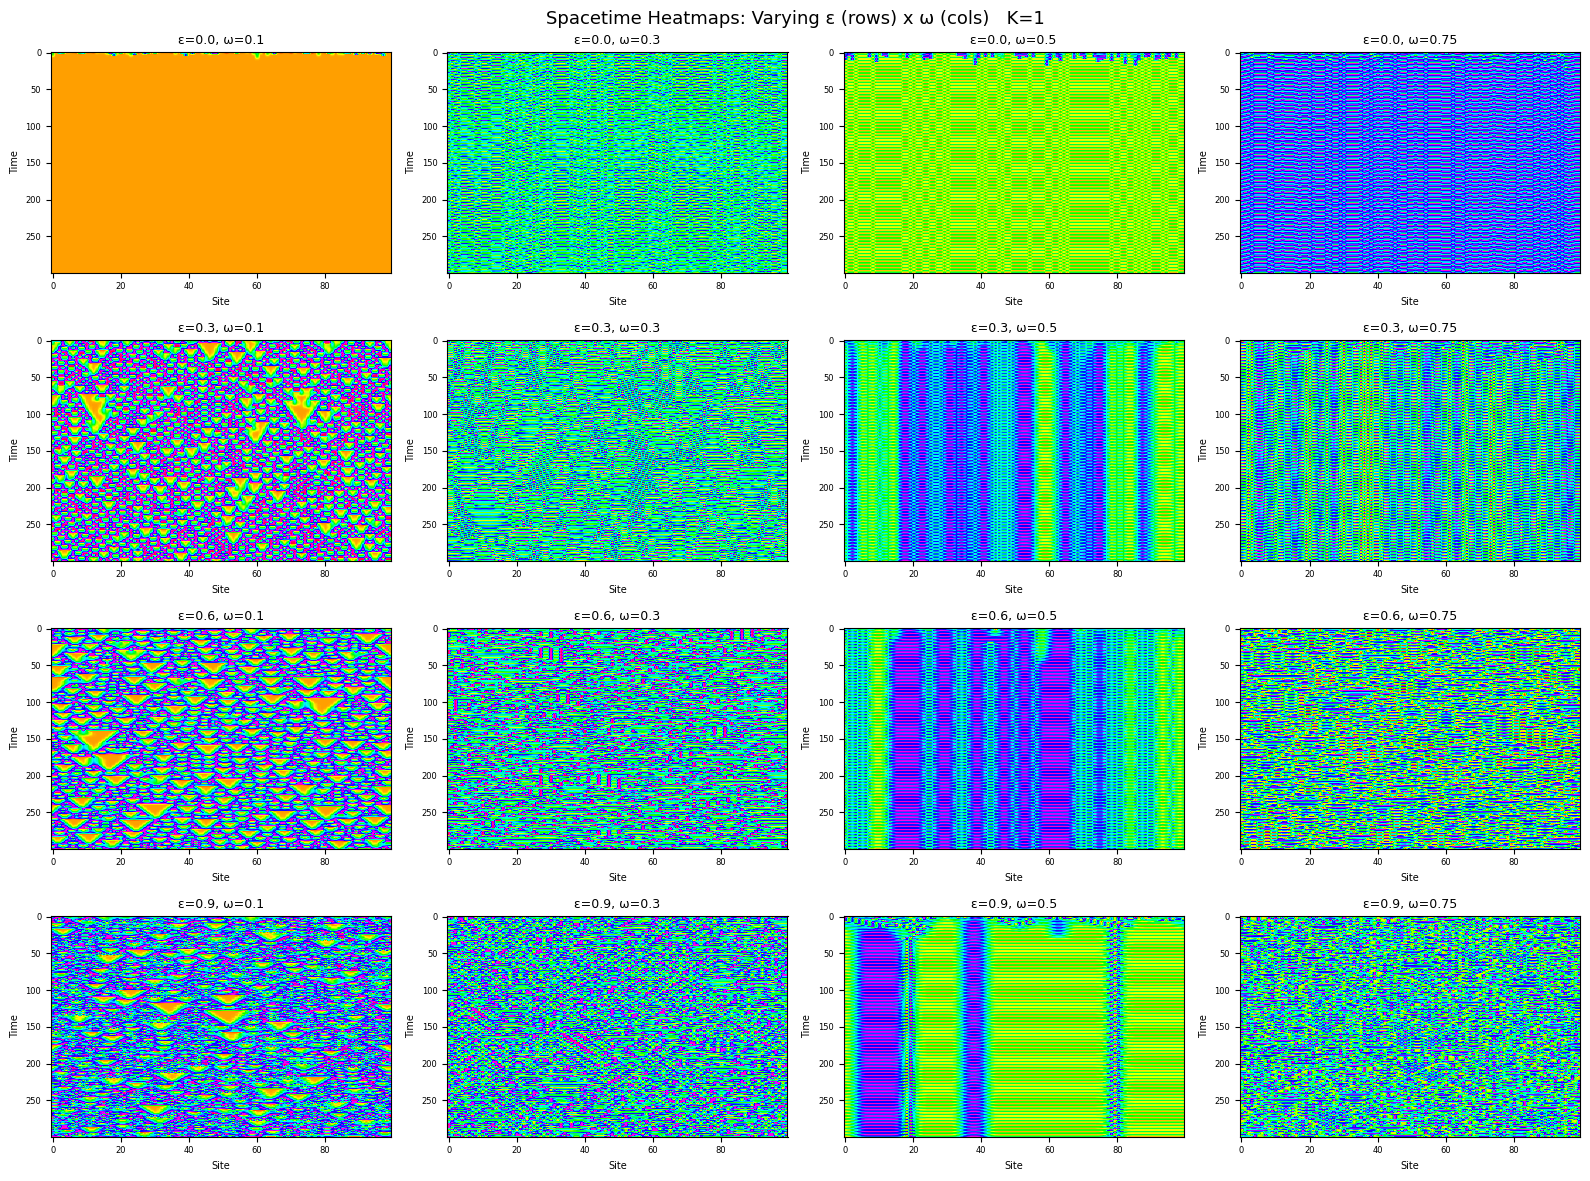

In [22]:
# Varying both ε and ω to see combined effects on spacetime patterns
epsilon_vals = [0.0, 0.3, 0.6, 0.9]
omega_vals   = [0.1, 0.3, 0.5, 0.75]

fig, axes = plt.subplots(len(epsilon_vals), len(omega_vals),
                          figsize=(4 * len(omega_vals), 3 * len(epsilon_vals)))

for i, eps in enumerate(epsilon_vals):
    for j, omg in enumerate(omega_vals):
        np.random.seed(42)
        theta_temp = np.random.rand(N)
        hist = np.zeros((T, N))
        hist[0] = theta_temp

        for t in range(1, T):
            f_theta = theta_temp + omg - (K / (2 * np.pi)) * np.sin(2 * np.pi * theta_temp)
            f_left  = np.roll(f_theta,  1)
            f_right = np.roll(f_theta, -1)
            theta_temp = ((1 - eps) * f_theta + (eps / 2) * (f_left + f_right)) % 1
            hist[t] = theta_temp

        ax = axes[i, j]
        ax.imshow(hist, aspect='auto', cmap='hsv', origin='upper', vmin=0, vmax=1)
        ax.set_title(f'ε={eps}, ω={omg}', fontsize=9)
        ax.set_xlabel('Site', fontsize=7)
        ax.set_ylabel('Time', fontsize=7)
        ax.tick_params(labelsize=6)

plt.suptitle(f'Spacetime Heatmaps: Varying ε (rows) x ω (cols)   K={K}', fontsize=13)
plt.tight_layout()
plt.savefig('Heatmap_eps_vs_omega.png', dpi=200, bbox_inches='tight')
plt.show()

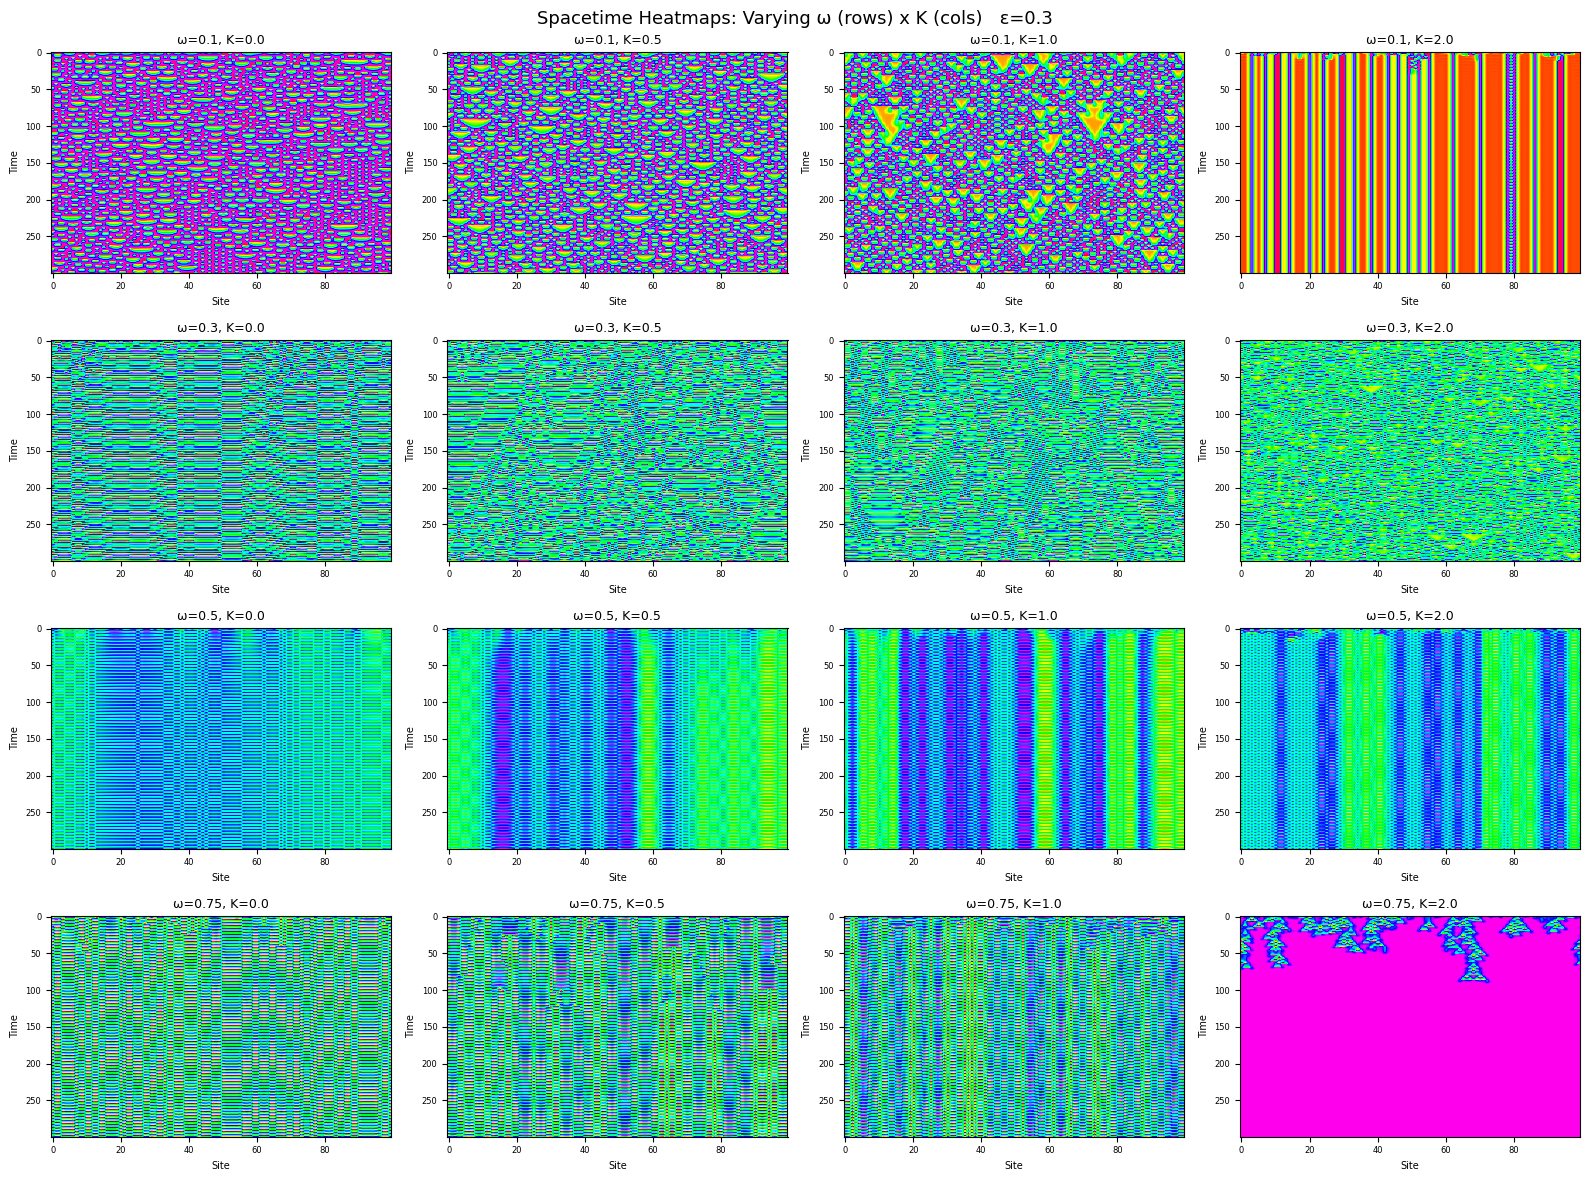

In [23]:
# Varying both ω and K to see combined effects on spacetime patterns
omega_vals = [0.1, 0.3, 0.5, 0.75]
K_vals     = [0.0, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(len(omega_vals), len(K_vals),
                          figsize=(4 * len(K_vals), 3 * len(omega_vals)))

for i, omg in enumerate(omega_vals):
    for j, K_val in enumerate(K_vals):
        np.random.seed(42)
        theta_temp = np.random.rand(N)
        hist = np.zeros((T, N))
        hist[0] = theta_temp

        for t in range(1, T):
            f_theta = theta_temp + omg - (K_val / (2 * np.pi)) * np.sin(2 * np.pi * theta_temp)
            f_left  = np.roll(f_theta,  1)
            f_right = np.roll(f_theta, -1)
            theta_temp = ((1 - epsilon) * f_theta + (epsilon / 2) * (f_left + f_right)) % 1
            hist[t] = theta_temp

        ax = axes[i, j]
        ax.imshow(hist, aspect='auto', cmap='hsv', origin='upper', vmin=0, vmax=1)
        ax.set_title(f'ω={omg}, K={K_val}', fontsize=9)
        ax.set_xlabel('Site', fontsize=7)
        ax.set_ylabel('Time', fontsize=7)
        ax.tick_params(labelsize=6)

plt.suptitle(f'Spacetime Heatmaps: Varying ω (rows) x K (cols)   ε={epsilon}', fontsize=13)
plt.tight_layout()
plt.savefig('Heatmap_omega_vs_K.png', dpi=200, bbox_inches='tight')
plt.show()

In [25]:
import matplotlib.animation as animation

for t in range(1, T):
    f_theta = theta + omega - (K / (2 * np.pi)) * np.sin(2 * np.pi * theta)
    f_left  = np.roll(f_theta,  1)
    f_right = np.roll(f_theta, -1)
    theta   = ((1 - epsilon) * f_theta + (epsilon / 2) * (f_left + f_right)) % 1
    history[t] = theta

# ── Animation ──────────────────────────────────────────────────────────────
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(10, 7),
                                      gridspec_kw={'height_ratios': [2, 1]})

# Top panel: scrolling spacetime heatmap (last 60 rows)
WINDOW = 60
heatmap_data = np.zeros((WINDOW, N))
im = ax_top.imshow(heatmap_data, aspect='auto', cmap='hsv',
                   origin='upper', vmin=0, vmax=1, animated=True)
ax_top.set_xlabel('Site index')
ax_top.set_ylabel(f'Last {WINDOW} time steps')
ax_top.set_title('')
fig.colorbar(im, ax=ax_top, label='Phase θ')

# Bottom panel: current spatial profile
x = np.arange(N)
(line,)   = ax_bot.plot(x, history[0], color='steelblue', lw=1.5)
scatter   = ax_bot.scatter(x, history[0],
                            c=history[0], cmap='hsv', vmin=0, vmax=1,
                            s=20, zorder=3)
ax_bot.set_xlim(0, N - 1)
ax_bot.set_ylim(-0.05, 1.05)
ax_bot.set_xlabel('Site index')
ax_bot.set_ylabel('Phase θ')
ax_bot.axhline(0.5, color='gray', linestyle='--', lw=0.7, alpha=0.5)
time_text = ax_bot.text(0.02, 0.92, '', transform=ax_bot.transAxes, fontsize=11)

plt.suptitle(f'CML Rotational Map Animation   ω={omega},  K={K},  ε={epsilon}', fontsize=12)
plt.tight_layout()


def init():
    heatmap_data[:] = 0
    im.set_data(heatmap_data)
    line.set_ydata(history[0])
    scatter.set_offsets(np.c_[x, history[0]])
    scatter.set_array(history[0])
    time_text.set_text('t = 0')
    return im, line, scatter, time_text


def update(frame):
    # Scrolling heatmap: shift up, paste new row at bottom
    row = frame % T
    heatmap_data[:-1] = heatmap_data[1:]
    heatmap_data[-1]  = history[row]
    im.set_data(heatmap_data.copy())

    # Spatial profile
    line.set_ydata(history[row])
    scatter.set_offsets(np.c_[x, history[row]])
    scatter.set_array(history[row])
    time_text.set_text(f't = {row}')
    return im, line, scatter, time_text


ani = animation.FuncAnimation(fig, update, frames=T,
                               init_func=init, interval=200,
                               blit=True, repeat=False)

ani.save('CML_animation.mp4', writer='ffmpeg', fps=8,
         extra_args=['-vcodec', 'libx264', '-pix_fmt', 'yuv420p'])

plt.close(fig)   # Don't open any window
print("Saved: CML_animation.mp4")

Saved: CML_animation.mp4
